# 08-Structured Streaming & Watermarks

In the previous seven lessons, we mastered Batch Processing. We ingested static files, optimized Catalyst execution plans, minimized network shuffles, executed window functions, and solved data skew with cryptographic salting.

However, Batch Processing assumes the dataset has a beginning and an end. In the modern Enterprise (e.g., IoT sensor telemetry, High-Frequency Trading, or Debezium CDC logs from Lesson 15), data never stops arriving. The dataset is **Unbounded**.

If you attempt to run a standard PySpark `.groupBy()` or `.window()` aggregation on an unbounded stream, the Catalyst engine will violently crash with an `OutOfMemoryError` (OOM). Why? Because to calculate an "average", the JVM must wait for all the data to arrive. Since the data never stops, the JVM holds the running state in memory forever until the server explodes.

To process infinite data, we must engineer **Structured Streaming**. Furthermore, to aggregate infinite data safely, we must inject a mathematical boundary known as a **Watermark** to guarantee state eviction.

Let's boot our cluster to master the physics of streaming state management.

In [3]:
# Required installations: pip install pyspark matplotlib seaborn
import os
import time
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import StructType, StructField, StringType, TimestampType, DoubleType
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Structured Streaming Engine Initialized.")

✅ Systems Architecture & Structured Streaming Engine Initialized.


# 1. The Mathematics of Unbounded State & Watermarks

### The Unbounded Table Theorem

Structured Streaming treats an incoming data stream (like a Kafka topic or a directory of incoming files) as an **Unbounded Table**. Every new record that arrives is mathematically appended to the bottom of this table.

$$\mathcal{T}_{stream} = [e_0, e_1, e_2, \dots, e_\infty]$$

Spark processes this infinite table using a **Micro-Batch Architecture**. It slices the stream into discrete temporal chunks (e.g., every 5 seconds) and processes them sequentially.

### The Problem of Late Data (State Explosion)

Assume we are aggregating revenue in 10-minute windows.
A user makes a purchase at 12:05 PM, but they are driving through a tunnel, so their mobile phone loses signal. Their phone finally reconnects and transmits the 12:05 PM event to Kafka at **1:15 PM**.

This is **Event Time vs. Processing Time**.
To accommodate this late-arriving data, the Spark Executor must keep the [12:00 - 12:10] aggregation window open in its active RAM state buffer. If it keeps all historical windows open forever waiting for delayed packets, the JVM memory state expands to infinity:


$$\lim_{t \to \infty} \text{Memory}(\mathcal{S}) = \text{OOM Crash}$$

### The Watermark Solution ($\mathcal{W}$)

A **Watermark** is a strict mathematical boundary that limits how late data can be before it is legally dropped, allowing the system to safely evict old state from RAM.

Let $T_{max}$ be the maximum Event Time observed by the engine so far.
Let $\Delta_{delay}$ be the user-defined Watermark threshold (e.g., "10 minutes").

The Watermark Boundary $\mathcal{W}$ dictates the oldest allowed timestamp:


$$\mathcal{W} = T_{max} - \Delta_{delay}$$

If a new event arrives with $T_{event} < \mathcal{W}$, the engine mathematically rejects it, classifying it as illegally late. This guarantees that any aggregation window falling behind $\mathcal{W}$ is permanently sealed, and its memory state is flushed to disk, preventing the crash.

# 2. Architecting the Streaming Engine

Let's build a real, executable Structured Streaming application.
Because we cannot easily mock a live Kafka broker in this notebook environment, we will use a **Socket Stream** (or a simulated file stream) to demonstrate the continuous execution loop. We will implement Windowed Aggregation and physically inject a Watermark.

In [4]:
# --- ⚙️ STEP 1: Booting the Streaming Cluster ---
spark = SparkSession.builder \
    .appName("Streaming_Physics") \
    .master("local[2]") \
    .config("spark.sql.shuffle.partitions", "2") \
    .getOrCreate() 
    # We constrain shuffle partitions to 2 for streaming to avoid micro-batch latency

# Ensure Spark operates in a silent mode so we can read our own outputs
spark.sparkContext.setLogLevel("ERROR")

# --- 📁 STEP 2: Creating the Simulation Directory ---
# We will simulate a stream by reading files dropped into a local folder
stream_dir = "./iot_stream_landing_zone"
os.makedirs(stream_dir, exist_ok=True)

# Define the strict schema (Streaming REQUIRES explicit schemas)
iot_schema = StructType([
    StructField("sensor_id", StringType(), True),
    StructField("event_time", TimestampType(), True),
    StructField("temperature", DoubleType(), True)
])

print("--- 📡 Establishing the Streaming Ingestion Pipeline ---")

# --- 📥 STEP 3: Connecting the Source (Extract) ---
# We use readStream instead of read
raw_stream_df = spark.readStream \
    .schema(iot_schema) \
    .json(stream_dir)

# --- 📐 STEP 4: Injecting the Watermark & Stateful Aggregation ---
print("--- 🛡️ Defining Stateful Bounding & Watermarks ---")

# 1. Define the Watermark Boundary: Allow data to be up to 15 minutes late.
# 2. Define the Window Geometry: Group data into 10-minute tumbling blocks based on Event Time.
aggregated_stream = raw_stream_df \
    .withWatermark("event_time", "15 minutes") \
    .groupBy(
        F.window(F.col("event_time"), "10 minutes"), 
        "sensor_id"
    ) \
    .agg(F.avg("temperature").alias("avg_temp"))

print("✅ Mathematical Topologies Compiled. Notice: The stream is NOT running yet.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:29:21 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:29:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 15:29:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 15:29:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


--- 📡 Establishing the Streaming Ingestion Pipeline ---
--- 🛡️ Defining Stateful Bounding & Watermarks ---
✅ Mathematical Topologies Compiled. Notice: The stream is NOT running yet.


# 3. Executing the Infinite Loop (The Sink)

A stream only begins flowing when we define a **Sink** (where the output goes) and call `.start()`.

In [5]:
# --- 🏁 STEP 5: Defining the Output Sink and Starting the Stream ---

# For demonstration, we will write the continuously updating aggregates directly into an in-memory table.
# In production, this would be `.format("delta")` or `.format("kafka")`.

streaming_query = aggregated_stream.writeStream \
    .outputMode("update") \
    .format("memory") \
    .queryName("live_sensor_dashboard") \
    .start()

print("\n--- 🚀 [STREAM ACTIVATED] Micro-Batch Engine is Running in Background ---")
print("Waiting for data to arrive in the landing zone...\n")

# --- ⚡ STEP 6: Simulating Live Data Injection ---
import json

# Batch 1: Normal Data arriving roughly on time
b1_data = [
    {"sensor_id": "SN-01", "event_time": "2026-06-24T12:05:00Z", "temperature": 72.5},
    {"sensor_id": "SN-02", "event_time": "2026-06-24T12:08:00Z", "temperature": 80.1}
]
with open(f"{stream_dir}/batch_1.json", "w") as f:
    for record in b1_data:
        f.write(json.dumps(record) + "\n")

# Sleep briefly to allow the Micro-Batch engine to process the file
time.sleep(4)

print("[Dashboard State after Batch 1]:")
spark.sql("SELECT window.start, sensor_id, avg_temp FROM live_sensor_dashboard ORDER BY start").show(truncate=False)


# Batch 2: The Late-Arriving Data Event
# The engine's $T_{max}$ is now 12:08. The Watermark $\mathcal{W}$ is (12:08 - 15m) = 11:53.
b2_data = [
    {"sensor_id": "SN-01", "event_time": "2026-06-24T12:12:00Z", "temperature": 74.0}, # Advances T_max to 12:12
    # LATE DATA: This event actually happened at 12:02, but is arriving NOW.
    # Because 12:02 is > Watermark (11:57), it is perfectly valid! The state is still open.
    {"sensor_id": "SN-01", "event_time": "2026-06-24T12:02:00Z", "temperature": 99.9}  
]
with open(f"{stream_dir}/batch_2.json", "w") as f:
    for record in b2_data:
        f.write(json.dumps(record) + "\n")

time.sleep(4)

print("[Dashboard State after Batch 2 (Notice SN-01's first window updated dynamically!)]:")
spark.sql("SELECT window.start, sensor_id, avg_temp FROM live_sensor_dashboard ORDER BY start").show(truncate=False)

# Gracefully terminate the infinite loop to free local resources
streaming_query.stop()
print("--- 🛑 Streaming Query Safely Terminated ---")

print("\n--- 💡 Engineering Insight ---")
print("Look at the output of Batch 2. The late packet (12:02) successfully penetrated the aggregation state buffer. Spark automatically found the [12:00 - 12:10] window sitting in memory, recalculated the average temperature combining the old 72.5 reading with the new 99.9 reading, and pushed the updated result to the dashboard.")
print("If that packet had a timestamp of 11:30, Spark would have dropped it instantly, because the [11:30 - 11:40] memory state had already been legally evicted by the 15-minute watermark.")


--- 🚀 [STREAM ACTIVATED] Micro-Batch Engine is Running in Background ---
Waiting for data to arrive in the landing zone...



[Dashboard State after Batch 1]:
+-------------------+---------+--------+
|start              |sensor_id|avg_temp|
+-------------------+---------+--------+
|2026-06-24 15:00:00|SN-01    |72.5    |
|2026-06-24 15:00:00|SN-02    |80.1    |
+-------------------+---------+--------+

[Dashboard State after Batch 2 (Notice SN-01's first window updated dynamically!)]:
+-------------------+---------+--------+
|start              |sensor_id|avg_temp|
+-------------------+---------+--------+
|2026-06-24 15:00:00|SN-01    |86.2    |
|2026-06-24 15:00:00|SN-01    |72.5    |
|2026-06-24 15:00:00|SN-02    |80.1    |
|2026-06-24 15:10:00|SN-01    |74.0    |
+-------------------+---------+--------+

--- 🛑 Streaming Query Safely Terminated ---

--- 💡 Engineering Insight ---
Look at the output of Batch 2. The late packet (12:02) successfully penetrated the aggregation state buffer. Spark automatically found the [12:00 - 12:10] window sitting in memory, recalculated the average temperature combining the 

# 4. Visualizing the Physics of the Watermark

To fully comprehend how the Watermark boundary advances through spacetime, physically evicting memory buffers, we must map the temporal topology of the stream.

/tmp/ipykernel_15348/787072515.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 1.5), 2.5, 1.5, fill=True, color='#bdc3c7', edgecolor='black', linewidth=1.5, hatch='//'))
/tmp/ipykernel_15348/787072515.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((3.5, 1.5), 2.5, 1.5, fill=True, color='#f1c40f', alpha=0.4, edgecolor='black', linewidth=2))
/tmp/ipykernel_15348/787072515.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((6.0, 1.5), 2.5, 1.5, fill=True, color='#f1c40f', alpha=0.4, edgecolor='black', linewidth=2))


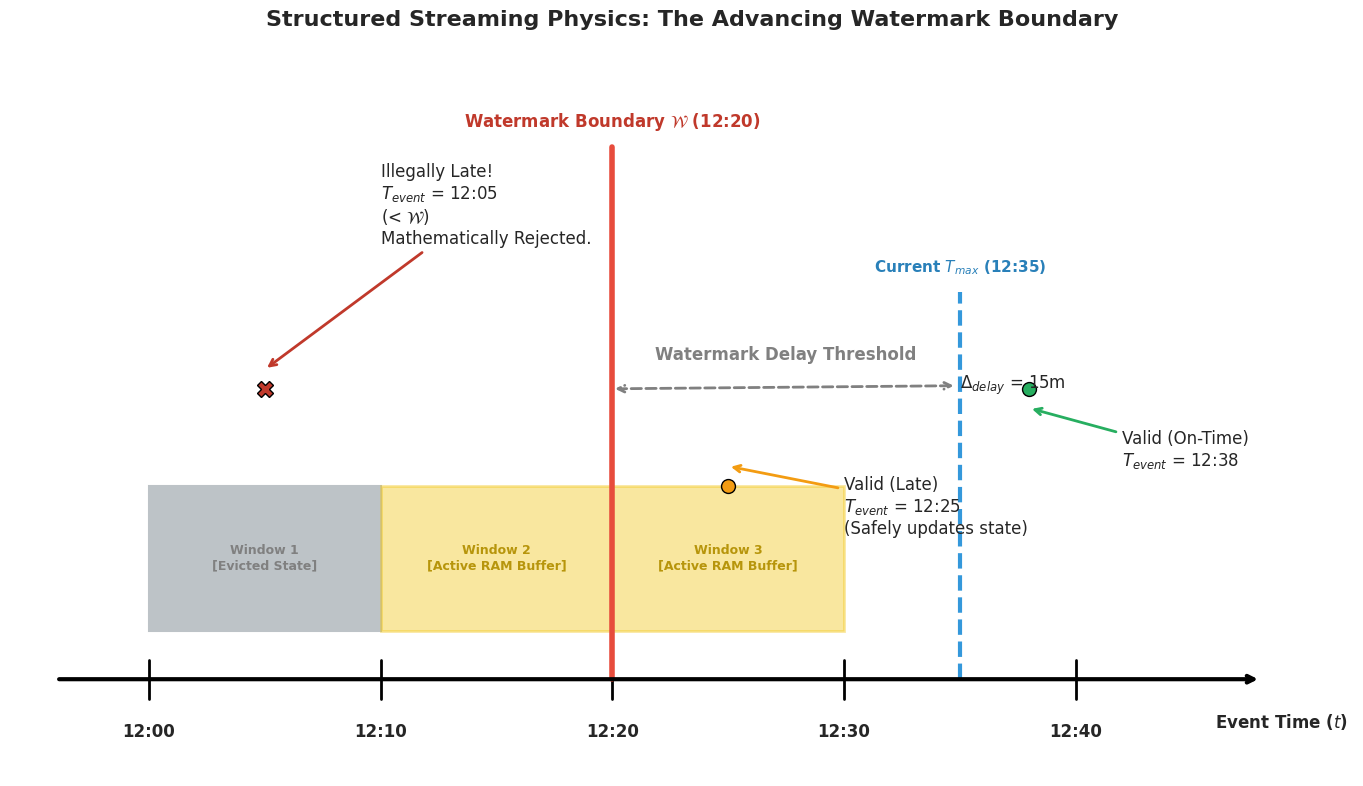

In [6]:
# Visualizing Watermark Execution Physics
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Structured Streaming Physics: The Advancing Watermark Boundary", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Spacetime Axis (Event Time)
ax.annotate("", xy=(13, 1), xytext=(0, 1), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(12.5, 0.5, "Event Time ($t$)", fontweight='bold', fontsize=12)

# Draw Time Markers
times = ["12:00", "12:10", "12:20", "12:30", "12:40"]
for i, t in enumerate(times):
    x = 1 + (i * 2.5)
    ax.plot([x, x], [0.8, 1.2], color='black', lw=2)
    ax.text(x, 0.4, t, ha='center', fontweight='bold')

# 2. Aggregation Windows (The State Memory Buffers)
# Window 1 [12:00 - 12:10] - EVICTED
ax.add_patch(patches.Rectangle((1.0, 1.5), 2.5, 1.5, fill=True, color='#bdc3c7', edgecolor='black', linewidth=1.5, hatch='//'))
ax.text(2.25, 2.25, "Window 1\n[Evicted State]", ha='center', va='center', color='gray', fontweight='bold', fontsize=9)

# Window 2 [12:10 - 12:20] - ACTIVE
ax.add_patch(patches.Rectangle((3.5, 1.5), 2.5, 1.5, fill=True, color='#f1c40f', alpha=0.4, edgecolor='black', linewidth=2))
ax.text(4.75, 2.25, "Window 2\n[Active RAM Buffer]", ha='center', va='center', color='#b7950b', fontweight='bold', fontsize=9)

# Window 3 [12:20 - 12:30] - ACTIVE
ax.add_patch(patches.Rectangle((6.0, 1.5), 2.5, 1.5, fill=True, color='#f1c40f', alpha=0.4, edgecolor='black', linewidth=2))
ax.text(7.25, 2.25, "Window 3\n[Active RAM Buffer]", ha='center', va='center', color='#b7950b', fontweight='bold', fontsize=9)


# 3. The Mathematical Pointers ($T_{max}$ and $\mathcal{W}$)
# Maximum Event Time observed by the engine (e.g., 12:35)
t_max_x = 9.75
ax.plot([t_max_x, t_max_x], [1, 5], color='#3498db', linestyle='--', linewidth=3)
ax.text(t_max_x, 5.2, "Current $T_{max}$ (12:35)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# The Watermark (e.g., 15 minutes behind T_max -> 12:20)
watermark_x = 6.0
ax.plot([watermark_x, watermark_x], [1, 6.5], color='#e74c3c', linestyle='-', linewidth=4)
ax.text(watermark_x, 6.7, "Watermark Boundary $\\mathcal{W}$ (12:20)", ha='center', color='#c0392b', fontweight='bold', fontsize=12)
ax.annotate("$\\Delta_{delay}$ = 15m", xy=(watermark_x, 4), xytext=(t_max_x, 4), arrowprops=dict(arrowstyle="<->", lw=2, color="gray", linestyle='dashed'))
ax.text(7.875, 4.3, "Watermark Delay Threshold", ha='center', fontweight='bold', color='gray')


# 4. Simulating Incoming Data Packets (Points in Spacetime)
# Valid On-Time Packet
ax.plot([10.5], [4], marker='o', markersize=10, color='#27ae60', markeredgecolor='black')
ax.annotate("Valid (On-Time)\n$T_{event}$ = 12:38", xy=(10.5, 3.8), xytext=(11.5, 3.2), arrowprops=dict(arrowstyle="->", lw=2, color="#27ae60"))

# Valid Late Packet (Penetrates the active buffer safely)
ax.plot([7.25], [3], marker='o', markersize=10, color='#f39c12', markeredgecolor='black')
ax.annotate("Valid (Late)\n$T_{event}$ = 12:25\n(Safely updates state)", xy=(7.25, 3.2), xytext=(8.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="#f39c12"))

# Illegal Dropped Packet (Hits the eviction wall)
ax.plot([2.25], [4], marker='X', markersize=12, color='#c0392b', markeredgecolor='black')
ax.annotate("Illegally Late!\n$T_{event}$ = 12:05\n(< $\\mathcal{W}$)\nMathematically Rejected.", xy=(2.25, 4.2), xytext=(3.5, 5.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b"))


plt.xlim(-0.5, 14)
plt.ylim(0, 7.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Structured Streaming and Watermarks like **Closing the Registers at a massive Election Voting Center**:

* **Stateless System (No Aggregation)**: People walk in, hand their ballot to a clerk, and the clerk immediately throws it into a box. Easy, fast, no memory required.
* **Stateful System without Watermarks (The OOM Crash)**: The voting center tries to keep a running tally of votes for every district in the country. The polls close at 8:00 PM. But the center keeps the district tally books open *forever* just in case a mail-in ballot arrives 5 years from now. Because they never close a book, the workers are overwhelmed by millions of open ledger books, they run out of desks (RAM), and the entire election system crashes.
* **Structured Streaming with Watermarks (The Legal Deadline)**: The government enforces a mathematical deadline (The Watermark). *"Polls close at 8:00 PM ($T_{max}$). We will accept mail-in ballots delayed by up to 3 days ($\Delta_{delay}$). Therefore, the Watermark ($\mathcal{W}$) is 3 Days."*
* If a ballot arrives 2 days late, the clerk opens the active tally book (The Window Buffer), updates the vote, and closes it.
* At exactly 8:00 PM on Day 3, the Watermark advances past the election deadline. The government officially signs the tally book, seals it in a vault (Evicts state from RAM), and declares the results final. If a ballot arrives on Day 4, it hits the Watermark wall and is instantly shredded. The system remains highly performant and stable.